In [1]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi 
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [2]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [3]:
modeApi = lumapi.MODE(hide=False)

#units

um = 1e-6
nm = 1e-9

#wavelength

wavelength = 1550 * nm
start_wavelength = 1500 * nm
stop_wavelength = 1600 * nm

# Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

# Dimensions

wvg_width = 450 * nm
wvg_height = 220 * nm
wvg_length = 3*um
WM = 7 * um
taper_length = 15 * um
taper_max_height = 1.5 * um
L = 178.5 * um

n_c = 1.5 # Refractive index of cladding
n_r = 3.5 # Refractive index of core
sigma = 0 # Conductivity of core
N = 2 # Number of desired imagens in the output

n_eff_array = np.loadtxt('neff_core.txt') # Exporting the effective index of the modes
beta_array = (2*np.pi/wavelength)*n_eff_array

We = WM + (wavelength / np.pi) * np.power(n_c / n_r,  2*sigma) * np.power(n_r**2 - n_c**2, -0.5)

## Construção o dispositivo ##

In [4]:
modeApi.addrect()
modeApi.set('name', 'central box')
modeApi.set('x', 0)
modeApi.set('x span', L)
modeApi.set('y', 0)
modeApi.set('y span', WM)
modeApi.set('z', 0)
modeApi.set('z span', wvg_height)
modeApi.set('material', material)

x_tapers = [(L+taper_length)/2, (L+taper_length)/2, -(L+taper_length)/2, -(L+taper_length)/2]
y_tapers = [We/6, -We/6, We/6, -We/6]
width_l_tapers = [taper_max_height, taper_max_height, wvg_width, wvg_width]
width_r_tapers = [wvg_width, wvg_width, taper_max_height, taper_max_height]

for i in range(0,4,1):
    modeApi.addobject('linear_taper')
    modeApi.set('name', 'taper_%d' %(i+1))
    modeApi.set('x', x_tapers[i])
    modeApi.set('len', taper_length)
    modeApi.set('y', y_tapers[i])
    modeApi.set('width_l', width_l_tapers[i])
    modeApi.set('width_r', width_r_tapers[i])
    modeApi.set('z', 0)
    modeApi.set('thickness', wvg_height)
    modeApi.set('angle_side', 90)
    modeApi.set('material', material)

x_guias = [(L+2*taper_length+wvg_length)/2, (L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2]

for i in range(0,4,1):
    modeApi.addrect()
    modeApi.set('name', 'wvg_%d' %(i+1))
    modeApi.set('x', x_guias[i])
    modeApi.set('x span', wvg_length)
    modeApi.set('y', y_tapers[i])
    modeApi.set('y span', wvg_width)
    modeApi.set('z', 0)
    modeApi.set('z span', wvg_height)
    modeApi.set('material', material)

## Definindo o solver varFDTD ##

In [5]:
## add solver

modeApi.addvarfdtd()


bound_x_offset = 0.5*um
bound_z_offset = 0.5*um

port_y_span = 1*um
port_z_span = 1*um

## Dimensions
modeApi.set('x',0)
modeApi.set('x span', (L + 2*taper_length + wvg_length))
modeApi.set('y', 0)
modeApi.set('y span', 3.5*WM)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span + 2*bound_z_offset)

## Banckground material
modeApi.set('background material', sub_material)

## Bandwidth, mesh accuracy simulation time and frequency points
modeApi.set('bandwidth', 'broadband')
modeApi.set('fit tolerance', 1e-2)
modeApi.set('mesh accuracy', 3)
modeApi.set('simulation time', 5*(L + 2*taper_length + wvg_length)/c)
modeApi.set('global monitor frequency points', 21)

In [6]:
modeApi.set('x0', x_tapers[3]+9*um)
modeApi.set('y0', We/6)

test_points = np.array([[x_tapers[3] + 9*um, 7*um],
                        [x_tapers[3] + 9*um, -7*um],
                        [x_tapers[1] - 9*um, We/6],
                        [x_tapers[1] - 9*um, -We/6]])

modeApi.set('test points', test_points)

modeApi.set('z max bc', 'PML')
modeApi.set('z min bc', 'Symmetric')

In [7]:
modeApi.addmodesource()
modeApi.set('injection axis', 'x')
modeApi.set('mode selection', 'fundamental mode')
modeApi.set('x', x_guias[3] + 0.5*um)
modeApi.set('y', We/6)
modeApi.set('y span', 3*um)
modeApi.set('wavelength start', start_wavelength)
modeApi.set('wavelength stop', stop_wavelength)

modeApi.addpower()
modeApi.set('name', 'port_1')
modeApi.set('monitor type', 5)
modeApi.set('x', x_guias[3]+1*um)
modeApi.set('y', We/6)
modeApi.set('z', 0)
modeApi.set('y span', 2*um)
modeApi.set('z span', 2*um)

modeApi.addpower()
modeApi.set('name', 'port_2')
modeApi.set('monitor type', 5)
modeApi.set('x', x_guias[1]-1*um)
modeApi.set('y', We/6)
modeApi.set('z', 0)
modeApi.set('y span', 2*um)
modeApi.set('z span', 2*um)

modeApi.addpower()
modeApi.set('name', 'port_3')
modeApi.set('monitor type', 5)
modeApi.set('x', x_guias[1]-1*um)
modeApi.set('y', -We/6)
modeApi.set('z', 0)
modeApi.set('y span', 2*um)
modeApi.set('z span', 2*um)

modeApi.addprofile()
modeApi.set('name', 'profile')
modeApi.set('x', 0)
modeApi.set('y', 0)
modeApi.set('x span', (L + 2*taper_length + wvg_length))
modeApi.set('y span', 5*WM)

## Realizando a simulação ##

In [8]:
modeApi.save('MMI_varFDTD')
modeApi.run()

In [9]:
eField = np.abs(np.squeeze(modeApi.getelectric('profile')))

x_efield = modeApi.getdata('profile', 'x')
y_efield = modeApi.getdata('profile', 'y')
wavelength_array = nu2lambda(modeApi.getdata('profile', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

central_wavelength_index = np.argmin(np.abs(wavelength_array[:,0] - 1.55*um))

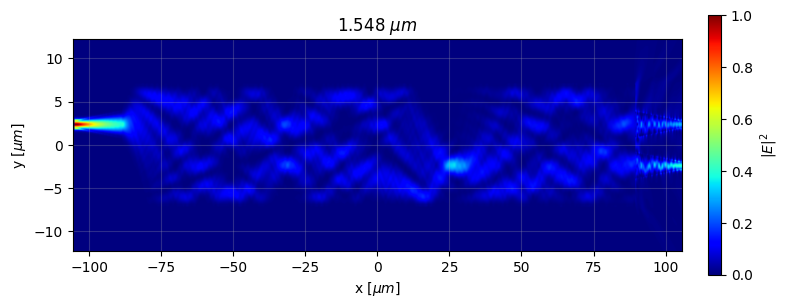

In [10]:
# Escala linear
eField_normalized = eField[:,:,central_wavelength_index]/np.max(eField[:,:,central_wavelength_index])

fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(np.rot90(eField_normalized), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = plt.get_cmap('jet'))

colorbar = plt.colorbar(im,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [$\mu m$]')

ax.set_title(r'%4.3f $\mu m$' % (wavelength_array[central_wavelength_index,0]/ um))
ax.grid(which='major', alpha = 0.25)
ax.set_aspect(3)

plt.tight_layout()
plt.show()

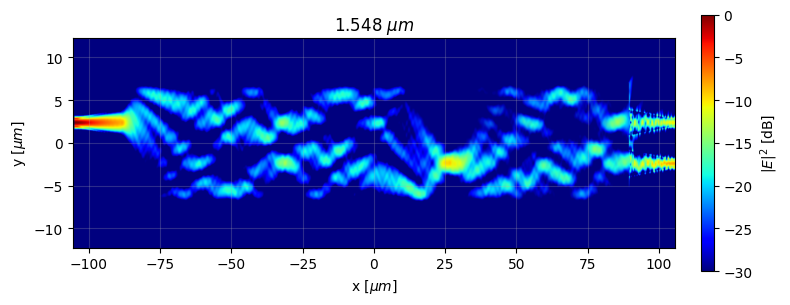

In [11]:
eField2 = np.power(eField,2)

eField2_normalized = eField2[:,:,central_wavelength_index]/np.max(eField2[:,:,central_wavelength_index])

eField2_dB = 10*np.log10(eField2_normalized)

fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(np.rot90(eField2_dB), extent=[xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = plt.get_cmap('jet'))

colorbar = plt.colorbar(im,fraction = 0.02, pad =0.04, label = r'$|E|^2$ [dB]')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [$\mu m$]')

ax.set_title(r'%4.3f $\mu m$' % (wavelength_array[central_wavelength_index,0]/ um))
ax.grid(which='major', alpha = 0.25)
ax.set_aspect(3)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Transmissão [$dB$] x Comprimento de Onda')

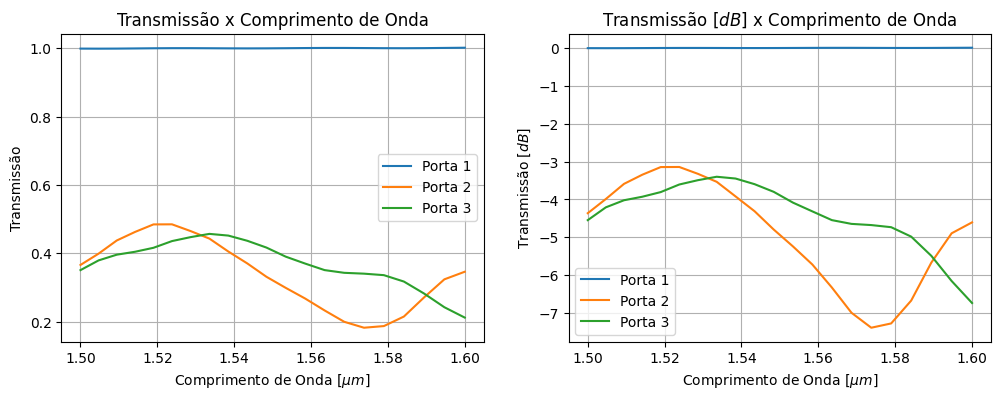

In [12]:
## Transmissão do dispositivo em cada porta
fig, ax = plt.subplots(1,2, figsize=(12,4))
for i in range(1,4,1):
    ports = modeApi.getresult('port_%d' %i, 'T')
    ax[0].plot(ports['lambda']/um, ports['T'], label = 'Porta %d' %i, linewidth = 1.5)
    ax[1].plot(ports['lambda']/um, 10*np.log10(ports['T']), label = 'Porta %d' %i, linewidth = 1.5)

ax[0].grid(True)
ax[0].legend(loc = 'best')
ax[0].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão')
ax[0].set_title(r'Transmissão x Comprimento de Onda')

ax[1].grid(True)
ax[1].legend(loc = 'best')
ax[1].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão [$dB$]')
ax[1].set_title(r'Transmissão [$dB$] x Comprimento de Onda')

Text(0.5, 1.0, 'Transmissão total [$dB$] x Comprimento de Onda')

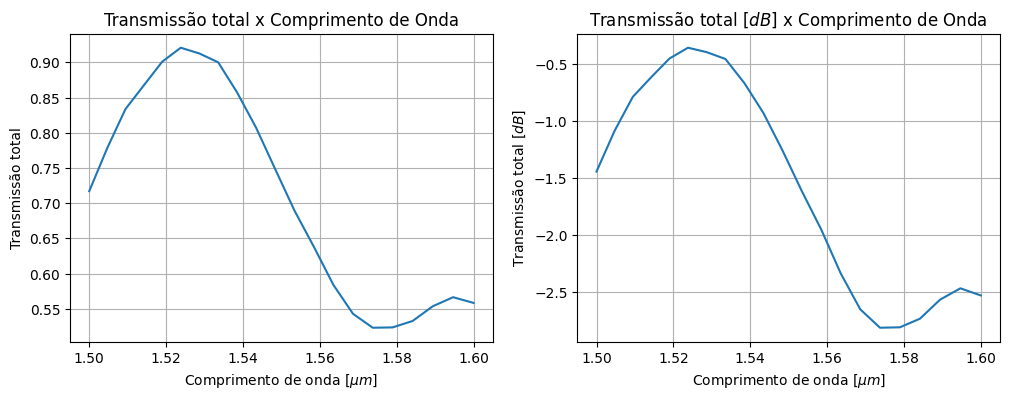

In [13]:
# Perda de inserção do dispositivo

T2 = (modeApi.getresult('port_2', 'T'))['T']
T3 = (modeApi.getresult('port_3', 'T'))['T']
wavelength_array = (modeApi.getresult('port_2', 'T'))['lambda']

total_transmission = T2 + T3
total_transmission_dB = 10*np.log10(total_transmission)

fig, ax = plt.subplots(1,2, figsize = (12,4))

ax[0].plot(wavelength_array/um, total_transmission, linewidth = 1.5)
ax[0].grid(True)
ax[0].set_xlabel(r'Comprimento de onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão total')
ax[0].set_title(r'Transmissão total x Comprimento de Onda')

ax[1].plot(wavelength_array/um, total_transmission_dB, linewidth = 1.5)
ax[1].grid(True)
ax[1].set_xlabel(r'Comprimento de onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão total [$dB$]')
ax[1].set_title(r'Transmissão total [$dB$] x Comprimento de Onda')

# Simulação para o modo TM #

In [14]:
modeApi.switchtolayout()

In [15]:
modeApi.select('varFDTD')
modeApi.set('polarization', 'H mode (TM)')
modeApi.set('z min bc', 'Anti-Symmetric')

In [16]:
modeApi.run()

In [17]:
eField = np.abs(np.squeeze(modeApi.getelectric('profile')))

x_efield = modeApi.getdata('profile', 'x')
y_efield = modeApi.getdata('profile', 'y')
wavelength_array = nu2lambda(modeApi.getdata('profile', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

central_wavelength_index = np.argmin(np.abs(wavelength_array[:,0] - 1.55*um))

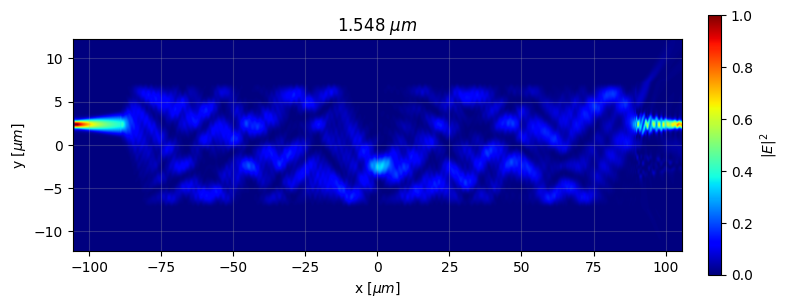

In [18]:
# Escala linear
eField_normalized = eField[:,:,central_wavelength_index]/np.max(eField[:,:,central_wavelength_index])

fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(np.rot90(eField_normalized), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = plt.get_cmap('jet'))

colorbar = plt.colorbar(im,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [$\mu m$]')

ax.set_title(r'%4.3f $\mu m$' % (wavelength_array[central_wavelength_index,0]/ um))
ax.grid(which='major', alpha = 0.25)
ax.set_aspect(3)

plt.tight_layout()
plt.show()

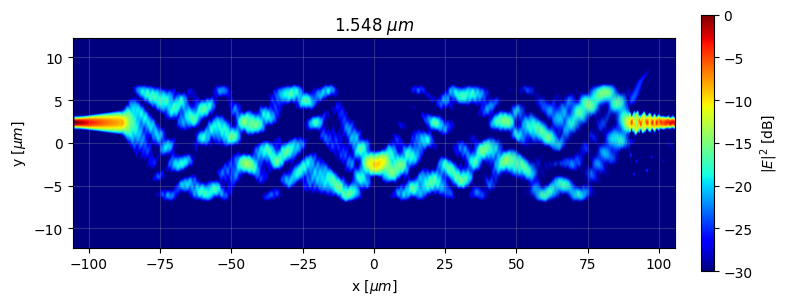

In [19]:
eField2 = np.power(eField,2)

eField2_normalized = eField2[:,:,central_wavelength_index]/np.max(eField2[:,:,central_wavelength_index])

eField2_dB = 10*np.log10(eField2_normalized)

fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(np.rot90(eField2_dB), extent=[xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = plt.get_cmap('jet'))

colorbar = plt.colorbar(im,fraction = 0.02, pad =0.04, label = r'$|E|^2$ [dB]')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [$\mu m$]')

ax.set_title(r'%4.3f $\mu m$' % (wavelength_array[central_wavelength_index,0]/ um))
ax.grid(which='major', alpha = 0.25)
ax.set_aspect(3)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Transmissão [$dB$] x Comprimento de Onda')

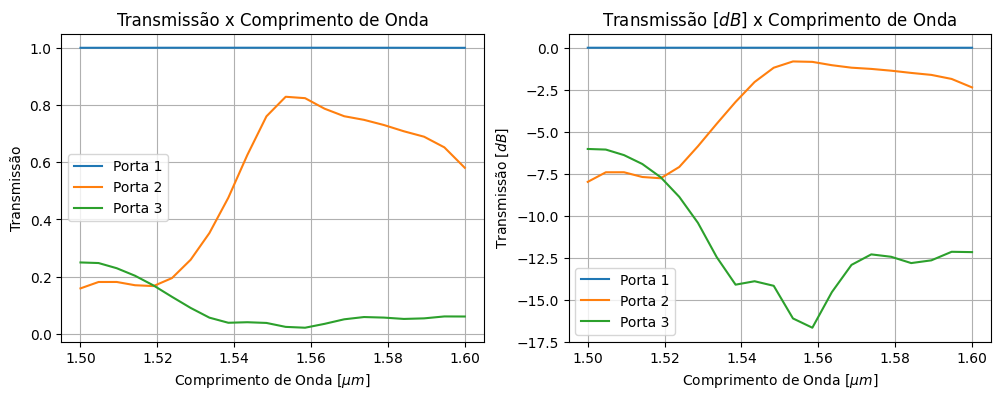

In [20]:
## Transmissão do dispositivo em cada porta
fig, ax = plt.subplots(1,2, figsize=(12,4))
for i in range(1,4,1):
    ports = modeApi.getresult('port_%d' %i, 'T')
    ax[0].plot(ports['lambda']/um, ports['T'], label = 'Porta %d' %i, linewidth = 1.5)
    ax[1].plot(ports['lambda']/um, 10*np.log10(ports['T']), label = 'Porta %d' %i, linewidth = 1.5)

ax[0].grid(True)
ax[0].legend(loc = 'best')
ax[0].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão')
ax[0].set_title(r'Transmissão x Comprimento de Onda')

ax[1].grid(True)
ax[1].legend(loc = 'best')
ax[1].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão [$dB$]')
ax[1].set_title(r'Transmissão [$dB$] x Comprimento de Onda')

Text(0.5, 1.0, 'Transmissão total [$dB$] x Comprimento de Onda')

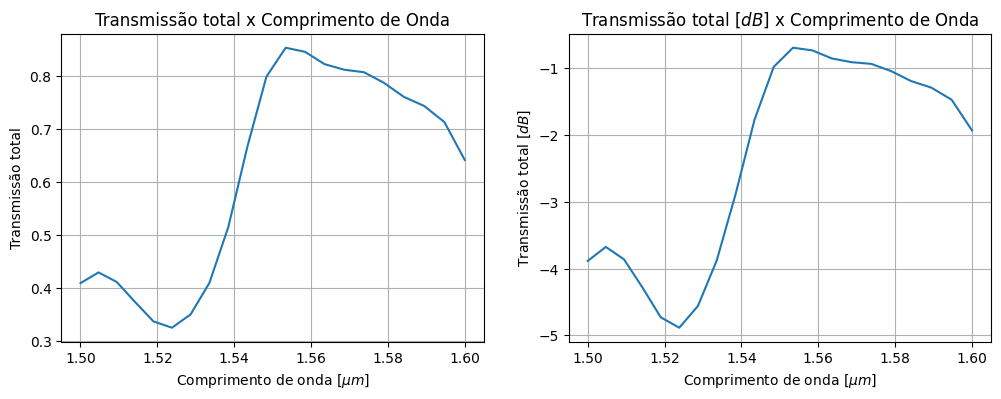

In [21]:
# Perda de inserção do dispositivo

T2 = (modeApi.getresult('port_2', 'T'))['T']
T3 = (modeApi.getresult('port_3', 'T'))['T']
wavelength_array = (modeApi.getresult('port_2', 'T'))['lambda']

total_transmission = T2 + T3
total_transmission_dB = 10*np.log10(total_transmission)

fig, ax = plt.subplots(1,2, figsize = (12,4))

ax[0].plot(wavelength_array/um, total_transmission, linewidth = 1.5)
ax[0].grid(True)
ax[0].set_xlabel(r'Comprimento de onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão total')
ax[0].set_title(r'Transmissão total x Comprimento de Onda')

ax[1].plot(wavelength_array/um, total_transmission_dB, linewidth = 1.5)
ax[1].grid(True)
ax[1].set_xlabel(r'Comprimento de onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão total [$dB$]')
ax[1].set_title(r'Transmissão total [$dB$] x Comprimento de Onda')

In [22]:
modeApi.close()